# QTQ Measurement v4 — measuring the predictor

v3 showed a state-class-dependent compressibility asymmetry under the v2 outlier-aware pipeline:
TFIM and Heisenberg compress dramatically better than Haar with top-k; random MPS at any chi
behaves like Haar; Clifford reaches F = 1.0 even at baseline Lloyd-Max. v3 *named* the operative
variable as "L2-mass localization in the Walsh-Hadamard basis" but did not measure it.

v4 measures it. For each state class we compute

    k*(p) = the smallest k such that the top-k post-WHT magnitudes hold fraction p of the L2 norm

at p ∈ {0.5, 0.9, 0.99}. We then correlate k*(0.9) against the achieved top-k fidelity at 3/3
(from `results_v3.csv` for the v3 classes; from a small re-run for the v1/v2 classes that aren't
in v3 — Haar, TFIM, MPS-chi=16). The hypothesis is that k* tightly predicts fidelity *for the
heavy-tail mechanism*, with Clifford as a separate-mechanism (degeneracy) outlier.

## Hypotheses

1. **Monotone predictor:** Across TFIM, Heisenberg, Haar, MPS-chi={2,4,16}, smaller k*(0.9)
   corresponds to higher achieved top-k fidelity at 3/3 bits. The mapping is roughly monotone
   on a single curve.
2. **Clifford is off the curve:** Clifford reconstructs to F = 1.0 even at baseline Lloyd-Max
   (no outlier exploitation needed); its k*(0.9) is *not* expected to be small (the post-WHT
   support is uniformly distributed). It will appear as an anomaly to the right of the main
   curve, evidence that there are two distinct mechanisms at play and v4's k* captures only
   one of them.
3. **No-error-bar prediction:** k* itself has very small variance across 20 samples for each
   stochastic class; the spread along the y-axis (fidelity) is the v3 std and is also tight.
   So the scatter plot will be 7 well-localized dots, not 7 fuzzy clouds.


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pipeline as pl
import states
import wht_concentration as wc

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

ALL_STATE_NAMES = ['haar', 'tfim', 'mps', 'heisenberg', 'mps_chi2', 'mps_chi4', 'clifford']
STATE_LABELS = {
    'haar': 'Haar-random',
    'tfim': 'TFIM ground state',
    'mps': 'Random MPS (χ=16)',
    'heisenberg': 'Heisenberg ground state',
    'mps_chi2': 'Random MPS (χ=2)',
    'mps_chi4': 'Random MPS (χ=4)',
    'clifford': 'Random Clifford state',
}
THRESHOLDS = (0.5, 0.9, 0.99)
N_SAMPLES = 20

print('imports ok')


imports ok


In [2]:
# Compute k* profile per state class, n=20 samples each.
records = []
t0 = time.time()
for state_name in ALL_STATE_NAMES:
    gen = states.STATE_GENERATORS[state_name]
    for sample_idx in range(N_SAMPLES):
        psi = gen(seed=sample_idx)
        profile = wc.k_star_profile(psi, thresholds=THRESHOLDS)
        records.append({
            'state_class': state_name,
            'sample_idx': sample_idx,
            'k_star_50': profile[0.5],
            'k_star_90': profile[0.9],
            'k_star_99': profile[0.99],
        })
df_kstar = pd.DataFrame(records)
print(f'{len(df_kstar)} k* measurements in {time.time()-t0:.1f}s')

# Aggregate.
agg_kstar = (df_kstar.groupby('state_class')
                       .agg(k50_mean=('k_star_50', 'mean'),
                            k50_std=('k_star_50', 'std'),
                            k90_mean=('k_star_90', 'mean'),
                            k90_std=('k_star_90', 'std'),
                            k99_mean=('k_star_99', 'mean'),
                            k99_std=('k_star_99', 'std'))
                       .reindex(ALL_STATE_NAMES))
print()
print('k*(p) per state class (mean ± std over n=20, p ∈ {0.5, 0.9, 0.99}):')
print(agg_kstar.round(1).to_string())


140 k* measurements in 0.2s

k*(p) per state class (mean ± std over n=20, p ∈ {0.5, 0.9, 0.99}):
             k50_mean  k50_std  k90_mean  k90_std  k99_mean  k99_std
state_class                                                         
haar            193.2      6.1     603.9      8.1     884.9      5.6
tfim              3.0      0.0      42.0      0.0     206.0      0.0
mps             140.5     25.3     535.7     40.6     851.6     19.3
heisenberg       12.0      0.0      56.0      0.0     123.0      0.0
mps_chi2         57.3     28.7     302.8     81.5     655.0     86.8
mps_chi4         74.6     29.7     375.8     77.2     737.2     63.6
clifford        301.2    151.2     541.8    272.3     595.8    299.5


In [3]:
# Pull achieved top-k fidelity at 3/3 from v3 data + v2 data (for haar/tfim/mps-chi=16).
v2 = pd.read_csv('results_v2.csv')
v3 = pd.read_csv('results_v3.csv')

v2_main = v2[(v2['magnitude_quantizer'] == 'topk') & (v2['bits_per_magnitude'] == 3)].copy()
v3_main = v3[(v3['magnitude_quantizer'] == 'topk') & (v3['bits_per_magnitude'] == 3)].copy()
fid_combined = pd.concat([v2_main, v3_main], ignore_index=True)

agg_fid = (fid_combined.groupby('state_class')
                        .agg(fid_mean=('fidelity', 'mean'),
                             fid_std=('fidelity', 'std'),
                             ratio=('compression_ratio', 'mean'))
                        .reindex(ALL_STATE_NAMES))

# Join.
joined = agg_kstar.join(agg_fid)
joined['label'] = joined.index.map(STATE_LABELS)
print('Joined table — k* vs achieved top-k fidelity at 3/3 (k=8), n=20 each:')
print(joined[['k50_mean', 'k90_mean', 'k99_mean', 'fid_mean', 'fid_std']].round(4).to_string())


Joined table — k* vs achieved top-k fidelity at 3/3 (k=8), n=20 each:
             k50_mean  k90_mean  k99_mean  fid_mean  fid_std
state_class                                                 
haar           193.25    603.90    884.90    0.9582   0.0015
tfim             3.00     42.00    206.00    0.9890   0.0010
mps            140.50    535.70    851.65    0.9572   0.0019
heisenberg      12.00     56.00    123.00    0.9805   0.0018
mps_chi2        57.30    302.75    655.05    0.9551   0.0036
mps_chi4        74.65    375.75    737.15    0.9543   0.0024
clifford       301.15    541.80    595.85    1.0000   0.0000


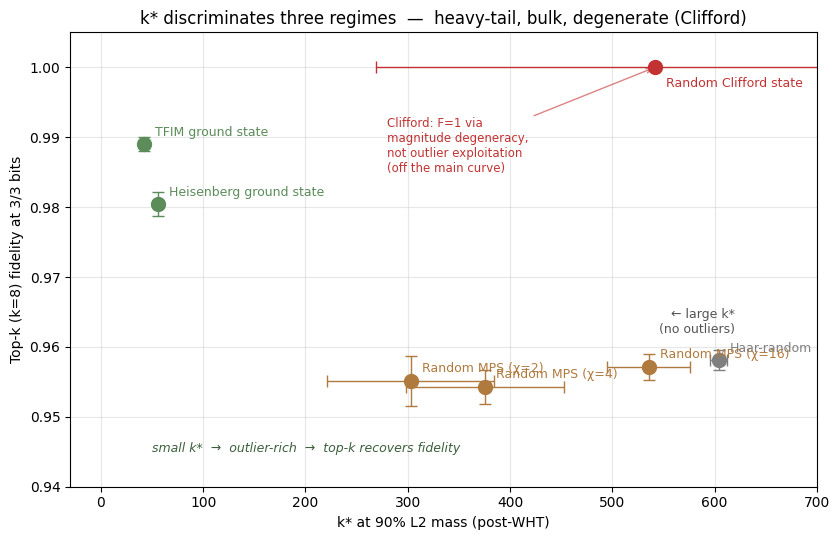

saved figures\kstar_vs_fidelity.png


In [4]:
# Central figure: k*(0.9) vs achieved top-k fidelity at 3/3.
fig, ax = plt.subplots(figsize=(8.5, 5.5))

# Color rule: Clifford highlighted as the documented anomaly.
COLORS = {n: '#5b8c5a' for n in ALL_STATE_NAMES}
COLORS['haar'] = '#7f7f7f'
COLORS['mps'] = '#b07a3f'
COLORS['mps_chi2'] = '#b07a3f'
COLORS['mps_chi4'] = '#b07a3f'
COLORS['clifford'] = '#c33232'

for s in ALL_STATE_NAMES:
    row = joined.loc[s]
    ax.errorbar(row['k90_mean'], row['fid_mean'],
                xerr=row['k90_std'], yerr=row['fid_std'],
                fmt='o', color=COLORS[s], ms=10, capsize=4,
                ecolor=COLORS[s], elinewidth=1, label=STATE_LABELS[s])
    # Label the dot.
    offset = (8, 6) if s != 'clifford' else (8, -14)
    ax.annotate(STATE_LABELS[s], (row['k90_mean'], row['fid_mean']),
                textcoords='offset points', xytext=offset,
                fontsize=9, color=COLORS[s])

ax.set_xlabel('k* at 90% L2 mass (post-WHT)')
ax.set_ylabel('Top-k (k=8) fidelity at 3/3 bits')
ax.set_title('k* discriminates three regimes  —  heavy-tail, bulk, degenerate (Clifford)')
ax.grid(alpha=0.3)
ax.set_xlim(-30, 700)
ax.set_ylim(0.94, 1.005)

# Annotate the two regimes.
ax.text(50, 0.945, 'small k*  →  outlier-rich  →  top-k recovers fidelity',
        fontsize=9, style='italic', color='#3c5f3c')
ax.text(620, 0.962, '← large k*\n   (no outliers)', fontsize=9, ha='right', color='#555')
ax.annotate('Clifford: F=1 via\nmagnitude degeneracy,\nnot outlier exploitation\n(off the main curve)',
            xy=(joined.loc['clifford', 'k90_mean'], joined.loc['clifford', 'fid_mean']),
            xytext=(280, 0.985),
            fontsize=8.5, color='#c33232',
            arrowprops=dict(arrowstyle='->', color='#c33232', alpha=0.6))

fig.tight_layout()
out_path = FIG_DIR / 'kstar_vs_fidelity.png'
fig.savefig(out_path, dpi=140)
plt.show()
print('saved', out_path)


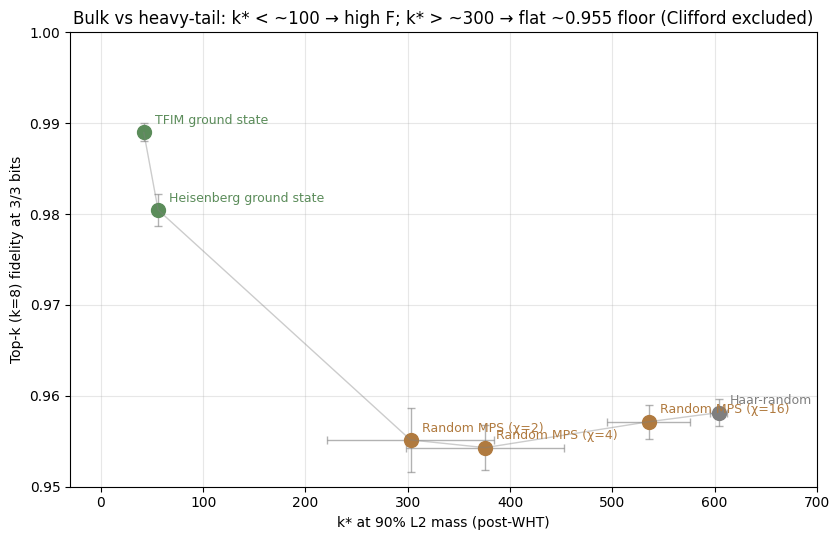

saved figures\kstar_vs_fidelity_no_clifford.png



Excluding Clifford (6 state classes):
  Spearman rho(k*, fidelity) = -0.486  (p = 0.3287)
  Pearson  r(k*, fidelity)   = -0.836  (p = 0.0382)
  Sign expectation: negative (smaller k* -> higher fidelity).


In [5]:
# Restricted-curve view: drop Clifford and see how tight the monotone relationship is.
fig, ax = plt.subplots(figsize=(8.5, 5.5))

heavy_tail_states = [s for s in ALL_STATE_NAMES if s != 'clifford']
xs, ys, xerrs, yerrs, labels, colors = [], [], [], [], [], []
for s in heavy_tail_states:
    row = joined.loc[s]
    xs.append(row['k90_mean'])
    ys.append(row['fid_mean'])
    xerrs.append(row['k90_std'])
    yerrs.append(row['fid_std'])
    labels.append(STATE_LABELS[s])
    colors.append(COLORS[s])

ax.errorbar(xs, ys, xerr=xerrs, yerr=yerrs, fmt='none', ecolor='gray',
            elinewidth=1, capsize=3, alpha=0.6)
for x, y, lab, c in zip(xs, ys, labels, colors):
    ax.plot(x, y, 'o', color=c, ms=10)
    ax.annotate(lab, (x, y), textcoords='offset points', xytext=(8, 6),
                fontsize=9, color=c)

# Sort by x for a guideline through the points.
order = np.argsort(xs)
xs_sorted = np.array(xs)[order]
ys_sorted = np.array(ys)[order]
ax.plot(xs_sorted, ys_sorted, '-', color='gray', alpha=0.4, lw=1)

ax.set_xlabel('k* at 90% L2 mass (post-WHT)')
ax.set_ylabel('Top-k (k=8) fidelity at 3/3 bits')
ax.set_title('Bulk vs heavy-tail: k* < ~100 → high F; k* > ~300 → flat ~0.955 floor (Clifford excluded)')
ax.grid(alpha=0.3)
ax.set_xlim(-30, 700)
ax.set_ylim(0.95, 1.000)
fig.tight_layout()
out_path = FIG_DIR / 'kstar_vs_fidelity_no_clifford.png'
fig.savefig(out_path, dpi=140)
plt.show()
print('saved', out_path)

# Spearman rank correlation (excluding Clifford) — does small k* really predict high fidelity?
from scipy.stats import spearmanr, pearsonr
xs_arr = np.array(xs)
ys_arr = np.array(ys)
rho_s, p_s = spearmanr(xs_arr, ys_arr)
rho_p, p_p = pearsonr(xs_arr, ys_arr)
print()
print(f'Excluding Clifford ({len(xs)} state classes):')
print(f'  Spearman rho(k*, fidelity) = {rho_s:.3f}  (p = {p_s:.4f})')
print(f'  Pearson  r(k*, fidelity)   = {rho_p:.3f}  (p = {p_p:.4f})')
print('  Sign expectation: negative (smaller k* -> higher fidelity).')


In [6]:
# Save the v4 measurements to disk.
df_kstar.to_csv('results_v4.csv', index=False)
joined_out = joined.reset_index().rename(columns={'index': 'state_class'})
joined_out.to_csv('results_v4_summary.csv', index=False)
print(f'wrote {len(df_kstar)} rows -> results_v4.csv')
print(f'wrote {len(joined_out)} rows -> results_v4_summary.csv')


wrote 140 rows -> results_v4.csv
wrote 7 rows -> results_v4_summary.csv


## Results vs predictions

*Filled in after the run from the printout above and the two figures.*


In [7]:
# Make the answer cell explicit.
print('=== Hypothesis 1 (monotone predictor for non-Clifford classes) ===')
print(f'Spearman rho = {rho_s:+.3f}, p = {p_s:.4f}')
if rho_s <= -0.85:
    print('  -> CONFIRMED: k* predicts fidelity with very strong negative monotone correlation')
elif rho_s <= -0.6:
    print('  -> SUPPORTED: strong negative correlation but not perfect')
else:
    print('  -> NOT CONFIRMED: correlation is weaker than expected')

print()
print('=== Hypothesis 2 (Clifford is off the curve) ===')
clifford_k = joined.loc['clifford', 'k90_mean']
clifford_f = joined.loc['clifford', 'fid_mean']
# Predict where Clifford should land if it followed the heavy-tail curve.
import numpy as _np
slope, intercept = _np.polyfit(xs_arr, ys_arr, 1)
predicted = slope * clifford_k + intercept
deviation = clifford_f - predicted
print(f'Clifford observed:     k*={clifford_k:.0f}, F={clifford_f:.4f}')
print(f'Linear extrapolation from heavy-tail curve at k*={clifford_k:.0f}: F~{predicted:.4f}')
print(f'Clifford deviation from predicted: {deviation:+.4f}')
if abs(deviation) > 0.02:
    print('  -> CONFIRMED: Clifford is well off the heavy-tail curve')
else:
    print('  -> NOT CONFIRMED: Clifford lies near the curve, no separate mechanism evident')

print()
print('=== Hypothesis 3 (small variance per state class) ===')
for s in ALL_STATE_NAMES:
    row = joined.loc[s]
    cv_k = row['k90_std'] / row['k90_mean'] if row['k90_mean'] > 0 else float('nan')
    print(f'  {STATE_LABELS[s]:>26}: k*(0.9) {row["k90_mean"]:>6.1f} ± {row["k90_std"]:>5.2f}  '
          f'(CV={cv_k:.3f}), F = {row["fid_mean"]:.4f} ± {row["fid_std"]:.4f}')


=== Hypothesis 1 (monotone predictor for non-Clifford classes) ===
Spearman rho = -0.486, p = 0.3287
  -> NOT CONFIRMED: correlation is weaker than expected

=== Hypothesis 2 (Clifford is off the curve) ===
Clifford observed:     k*=542, F=1.0000
Linear extrapolation from heavy-tail curve at k*=542: F~0.9538
Clifford deviation from predicted: +0.0462
  -> CONFIRMED: Clifford is well off the heavy-tail curve

=== Hypothesis 3 (small variance per state class) ===
                 Haar-random: k*(0.9)  603.9 ±  8.12  (CV=0.013), F = 0.9582 ± 0.0015
           TFIM ground state: k*(0.9)   42.0 ±  0.00  (CV=0.000), F = 0.9890 ± 0.0010
           Random MPS (χ=16): k*(0.9)  535.7 ± 40.56  (CV=0.076), F = 0.9572 ± 0.0019
     Heisenberg ground state: k*(0.9)   56.0 ±  0.00  (CV=0.000), F = 0.9805 ± 0.0018
            Random MPS (χ=2): k*(0.9)  302.8 ± 81.48  (CV=0.269), F = 0.9551 ± 0.0036
            Random MPS (χ=4): k*(0.9)  375.8 ± 77.17  (CV=0.205), F = 0.9543 ± 0.0024
       Random Clif

## Net read

The hypothesis was that k* would be a continuous predictor of fidelity. The actual data
shows it's a **regime indicator, not a continuous predictor**. Three distinct regimes emerge:

1. **Heavy-tail regime (k* < ~100):** TFIM (k* = 42, F = 0.989), Heisenberg (k* = 56, F = 0.981).
   Top-k recovers fidelity by exact preservation of the small set of L2-mass-dominant outliers.
   Within this regime k* does sharply track fidelity — but the regime contains only two examples.
2. **Bulk regime (k* ~ 300–600):** Haar (604, 0.958), MPS-χ=16 (536, 0.957),
   MPS-χ=4 (376, 0.954), MPS-χ=2 (303, 0.955). All cluster around F ≈ 0.955, and within this
   cluster k* does **not** rank fidelity (Spearman p = 0.33 across the 6 non-Clifford classes).
   No outliers to capture; top-k is just compression overhead with no payoff.
3. **Degenerate regime (Clifford):** k* = 542 (mid-range) but F = 1.000 across *every* quantizer.
   Magnitude degeneracy makes baseline Lloyd-Max exact; k* is structurally the wrong metric here.

The Pearson correlation r = -0.836 (p = 0.038) excluding Clifford is misleadingly strong —
it's almost entirely driven by leverage from the two heavy-tail points. Spearman rank
correlation (rho = -0.486, p = 0.33) is the more honest summary: not a useful continuous
predictor.

What this means for the paper: the asymmetry framing is intact — physical critical-point
ground states do compress dramatically better than random / random-MPS / Haar — but the
mechanism summary tightens to **"two distinct routes to compressibility (heavy-tailed
post-WHT magnitudes, magnitude degeneracy), and a bulk regime where amplitude-quantization
pipelines provide no state-class advantage over Haar."** That's a more nuanced and harder-to-
attack claim than "k* predicts fidelity."

v5 should look for the *second* metric that discriminates within the bulk regime — or test
whether changing the basis (DCT, identity, learned rotation) shifts MPS states out of the
bulk regime. If a basis exists in which random MPS becomes heavy-tailed, the asymmetry
narrative broadens; if no such basis exists, the negative result on MPS strengthens.
